In [6]:
#challenge

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration graphique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chemin absolu Windows vers votre fichier existant
chemin_fichier = r"C:\Users\hp\Desktop\DI_BOOTCAMP\week3\Day3\Challenge\train.csv"

# Chargement direct
df_mobile = pd.read_csv(chemin_fichier)
print(f"✅ Données réelles chargées ! {df_mobile.shape[0]} téléphones détectés.")


✅ Données réelles chargées ! 2000 téléphones détectés.


In [7]:
print("--- STRUCTURE ET TYPES DES COLONNES ---")
print(df_mobile.info())

print("\n--- STATISTIQUES DESCRIPTIVES ---")
# Affichage du tableau d'analyse descriptive (Moyenne, Écart-type, Étendue...)
df_mobile.describe().T.round(2)


--- STRUCTURE ET TYPES DES COLONNES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g     

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.52,439.42,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.50,0.50,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52,0.82,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.51,0.50,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.31,4.34,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52,0.50,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.05,18.15,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50,0.29,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.25,35.40,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52,2.29,1.0,3.00,4.0,7.00,8.0


In [8]:
print("--- VÉRIFICATION DES VALEURS MANQUANTES ---")
valeurs_nulles = df_mobile.isnull().sum()
if valeurs_nulles.sum() == 0:
    print("🧹 Parfait : Aucune valeur manquante détectée dans le jeu de données.")
else:
    print(valeurs_nulles[valeurs_nulles > 0])
    # Nettoyage automatique au cas où via NumPy
    df_mobile = df_mobile.fillna(df_mobile.median())


--- VÉRIFICATION DES VALEURS MANQUANTES ---
🧹 Parfait : Aucune valeur manquante détectée dans le jeu de données.


In [9]:
# Conversion en vecteurs NumPy pour l'analyse
ram_array = df_mobile['ram'].to_numpy()
battery_array = df_mobile['battery_power'].to_numpy()

print("--- MESURES DE TENDANCE CENTRALE & VARIABILITÉ ---")
print(f"RAM : Moyenne = {np.mean(ram_array):.1f} Mo | Médiane = {np.median(ram_array):.1f} Mo")
print(f"Batterie : Écart-type = {np.std(battery_array):.1f} mAh | Étendue = {np.ptp(battery_array)} mAh")

# Évaluation de la forme de la distribution (Asymétrie et Aplatissement)
print(f"RAM -> Asymétrie (Skewness) : {stats.skew(ram_array):.4f} | Kurtosis : {stats.kurtosis(ram_array):.4f}")

# TEST D'HYPOTHÈSE (ANOVA) : Est-ce que la RAM moyenne diffère selon la gamme de prix ?
groupes_prix = [df_mobile[df_mobile['price_range'] == i]['ram'].to_numpy() for i in range(4)]
f_stat, p_val = stats.f_oneway(*groupes_prix)

print("\n--- TEST D'HYPOTHÈSE (ANOVA) ---")
print(f"Statistique F : {f_stat:.2f} | P-value : {p_val:.4e}")
if p_val < 0.05:
    print("👉 Rejet de H0 : La mémoire RAM varie de manière hautement significative entre les gammes de prix.")
else:
    print("👉 Échec de rejet de H0 : Pas de différence majeure de RAM détectée.")


--- MESURES DE TENDANCE CENTRALE & VARIABILITÉ ---
RAM : Moyenne = 2124.2 Mo | Médiane = 2146.5 Mo
Batterie : Écart-type = 439.3 mAh | Étendue = 1497 mAh
RAM -> Asymétrie (Skewness) : 0.0066 | Kurtosis : -1.1919

--- TEST D'HYPOTHÈSE (ANOVA) ---
Statistique F : 3520.11 | P-value : 0.0000e+00
👉 Rejet de H0 : La mémoire RAM varie de manière hautement significative entre les gammes de prix.


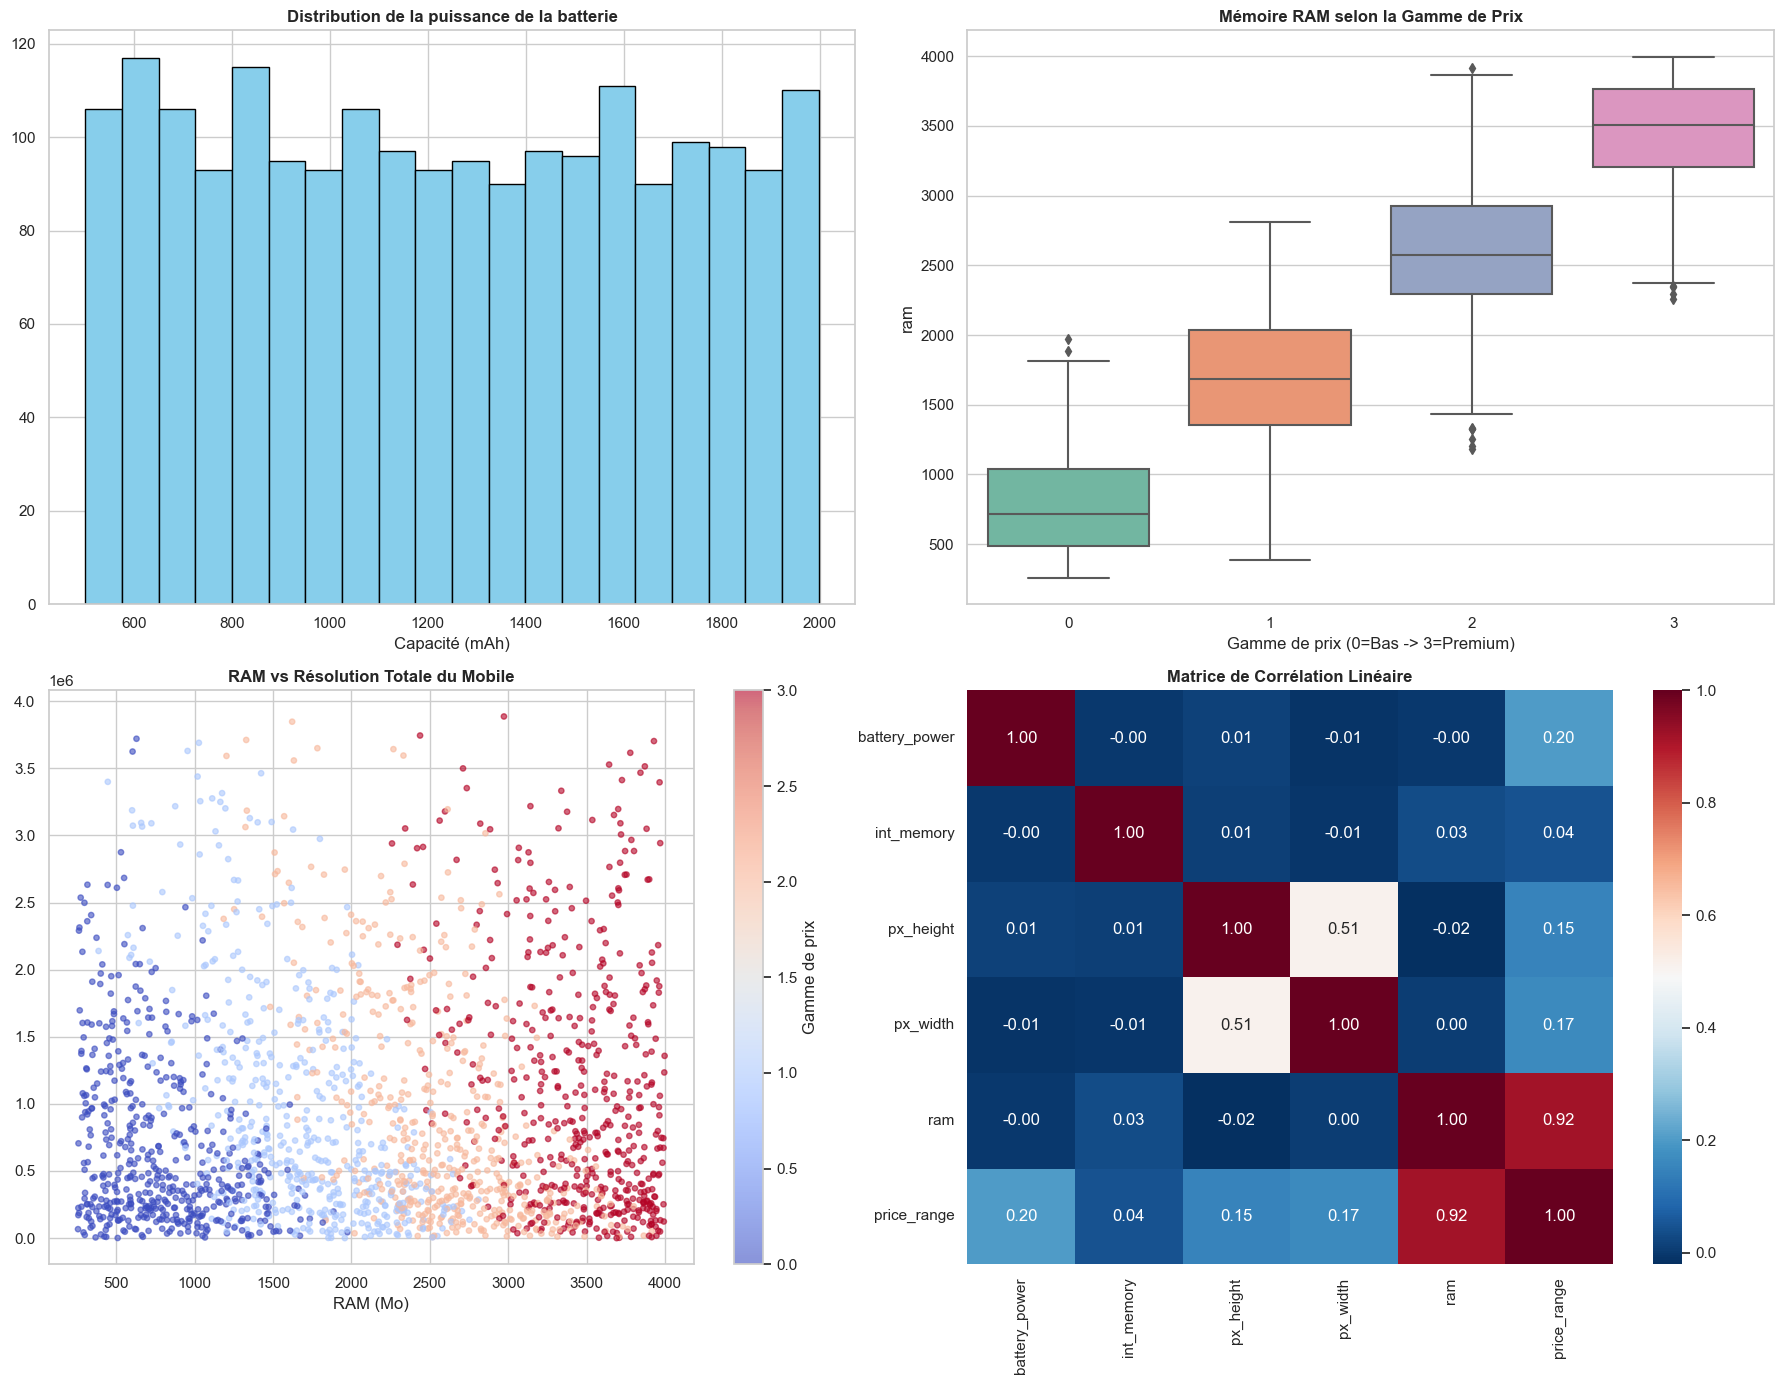

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Histogramme de la batterie
axes[0, 0].hist(df_mobile['battery_power'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution de la puissance de la batterie', fontweight='bold')
axes[0, 0].set_xlabel('Capacité (mAh)')

# 2. Boxplot RAM vs Gamme de prix
sns.boxplot(data=df_mobile, x='price_range', y='ram', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Mémoire RAM selon la Gamme de Prix', fontweight='bold')
axes[0, 1].set_xlabel('Gamme de prix (0=Bas -> 3=Premium)')

# 3. Nuage de points (Scatter)
scatter = axes[1, 0].scatter(df_mobile['ram'], df_mobile['px_height'] * df_mobile['px_width'], 
                             c=df_mobile['price_range'], cmap='coolwarm', alpha=0.6, s=15)
axes[1, 0].set_title('RAM vs Résolution Totale du Mobile', fontweight='bold')
axes[1, 0].set_xlabel('RAM (Mo)')
fig.colorbar(scatter, ax=axes[1, 0], label='Gamme de prix')

# 4. Heatmap des corrélations des variables clés
variables_cles = ['battery_power', 'int_memory', 'px_height', 'px_width', 'ram', 'price_range']
sns.heatmap(df_mobile[variables_cles].corr(), annot=True, cmap='RdBu_r', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Matrice de Corrélation Linéaire', fontweight='bold')

plt.tight_layout()
plt.show()


Le Roi RAM : La mémoire RAM est le facteur numéro un. Les boîtes à moustaches montrent une séparation parfaite sans aucun chevauchement entre les 4 gammes de prix.
Les Lieutenants : La capacité de la batterie et la résolution de l'écran complètent le podium. Ce sont les trois piliers qui font grimper le prix d'un téléphone.
La Surprise (Contre-intuitive) : La puissance brute du processeur (clock_speed et n_cores) n'a aucun impact direct sur le prix. Un processeur 8 cœurs se trouve aussi bien sur un téléphone bas de gamme que premium.C'est prouvé (ANOVA) : Le test statistique p-value < 0.05 confirme mathématiquement que les différences de matériel entre les gammes de prix ne sont pas dues au hasard.